Polynomial regression

In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [10]:
df = pd.read_csv("Salary_Data.csv")

In [11]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 314.4 KB


In [13]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='str')

In [ ]:
# Drop rows where Salary is missing first
df = df.dropna(subset=['Salary']).copy()

#  CLEAN STRINGS: Remove leading/trailing spaces and handle variations
# This is likely why your Education mapping failed
df['Education Level'] = df['Education Level'].str.strip() #type: ignore
df['Gender'] = df['Gender'].str.strip()

#  Updated Mapping (Handling variations like "Bachelor's Degree")
edu_map = {
    "High School": 0,
    "Bachelor's": 1,
    "Bachelor's Degree": 1,
    "Master's": 2,
    "Master's Degree": 2,
    "PhD": 3,
    "phD": 3
}
df['Education Level'] = df['Education Level'].map(edu_map)

#  Gender Mapping
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

#  Job Title Encoding
le = LabelEncoder()
df['Job Title'] = le.fit_transform(df['Job Title'].astype(str))  # type: ignore[assignment]


#  FINAL DROP: Now drop the few rows that couldn't be mapped
df = df.dropna()

print(df.info())

<class 'pandas.DataFrame'>
Index: 6684 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6684 non-null   float64
 1   Gender               6684 non-null   float64
 2   Education Level      6684 non-null   float64
 3   Job Title            6684 non-null   int64  
 4   Years of Experience  6684 non-null   float64
 5   Salary               6684 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 365.5 KB
None


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = df.drop('Salary', axis=1)
y = df['Salary']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import numpy as np

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

y_pred_poly = poly_reg.predict(X_test_poly)

poly_r2 = r2_score(y_test, y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("Polynomial Regression (deg=2) -> R2:", poly_r2, " RMSE:", poly_rmse)

Polynomial Regression (deg=2) -> R2: 0.8098763226851531  RMSE: 22985.579275787182


In [36]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

lin_r2 = r2_score(y_test, y_pred_lin)
lin_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print("Linear Regression -> R2:", lin_r2, " RMSE:", lin_rmse)

Linear Regression -> R2: 0.7108119213059388  RMSE: 28348.334151220835


In [37]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression (deg=2)"],
    "R2 Score": [lin_r2, poly_r2],
    "RMSE": [lin_rmse, poly_rmse]
})
results

,Model,R2 Score,RMSE
0,Linear Regression,0.710812,28348.334151
1,Polynomial Regression (deg=2),0.809876,22985.579276


In [38]:
# Use Years of Experience as the x-axis since it's usually the strongest predictor
feature_col = 'Years of Experience'

# Build a dataframe combining test features, actual, and predicted values
plot_df = X_test.copy()
plot_df['Actual'] = y_test.values
plot_df['Pred_Linear'] = y_pred_lin
plot_df['Pred_Poly'] = y_pred_poly

# Sort by the chosen feature so lines look clean instead of jumping around
plot_df = plot_df.sort_values(by=feature_col)

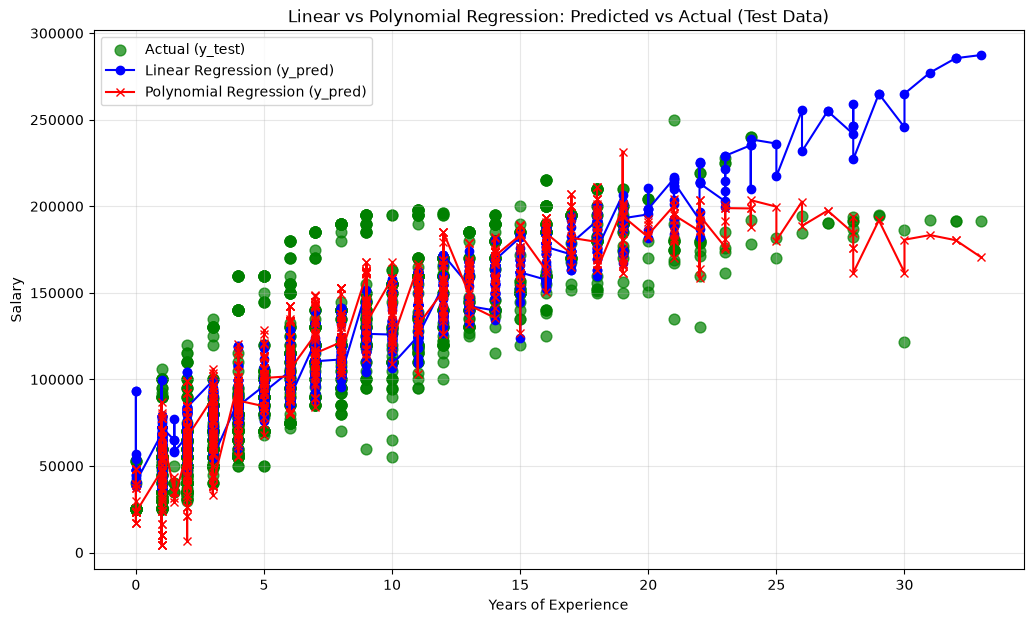

In [39]:
plt.figure(figsize=(12, 7))

# Actual test points
plt.scatter(plot_df[feature_col], plot_df['Actual'],
            color='green', label='Actual (y_test)', alpha=0.7, s=60)

# Linear regression predictions
plt.plot(plot_df[feature_col], plot_df['Pred_Linear'],
          color='blue', linestyle='-', marker='o', label='Linear Regression (y_pred)')

# Polynomial regression predictions
plt.plot(plot_df[feature_col], plot_df['Pred_Poly'],
          color='red', linestyle='-', marker='x', label='Polynomial Regression (y_pred)')

plt.xlabel(feature_col)
plt.ylabel("Salary")
plt.title("Linear vs Polynomial Regression: Predicted vs Actual (Test Data)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()